# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [2]:
df = pd.read_csv("../data/states_edu.csv")

You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [19]:
df.isna().sum()
df["AVG_MATH_8_SCORE"] = df["AVG_MATH_8_SCORE"].fillna(df["AVG_MATH_8_SCORE"].mean())
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_K',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)
df.columns
((df["ENROLL_ALL"] - df["ENROLL_ALL_EST"])/df["ENROLL_ALL"]).describe()
df["ENROLL_ALL_EST"] = df["ENROLL_ALL_EST"].fillna(df["ENROLL_ALL"])

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: Grade 8 Math

In [ ]:
#Grade 8 Math

How many years of data are logged in our dataset? 

In [11]:
# @@@ 1
df["YEAR"].nunique()

33

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [13]:
# @@@ 2


df.groupby(["STATE"])["AVG_MATH_8_SCORE"].mean()
#OHIO: 282.250000, MICHIGAN: 276.166667, so OHIO has higher average grade 8 math scores


STATE
ALABAMA                 273.148344
ALASKA                  278.749622
ARIZONA                 276.966526
ARKANSAS                275.178647
CALIFORNIA              274.966526
COLORADO                279.914427
CONNECTICUT             279.724101
DELAWARE                277.914427
DISTRICT_OF_COLUMBIA    268.421071
DODEA                   283.855274
FLORIDA                 276.672002
GEORGIA                 276.299859
HAWAII                  275.118041
IDAHO                   279.572586
ILLINOIS                278.490184
INDIANA                 279.724101
IOWA                    280.126548
KANSAS                  280.650206
KENTUCKY                276.845314
LOUISIANA               273.633192
MAINE                   280.187154
MARYLAND                278.511980
MASSACHUSETTS           282.975033
MICHIGAN                277.511980
MINNESOTA               282.542283
MISSISSIPPI             273.672002
MISSOURI                278.611396
MONTANA                 281.126548
NATIONAL      

Find the average for your chosen test across all states in 2019

In [16]:
# @@@ 3
df["AVG_MATH_8_SCORE"]
df.loc[df["YEAR"] == 2019, ["AVG_MATH_8_SCORE"]].mean()

AVG_MATH_8_SCORE    281.264151
dtype: float64

For each state, find a maximum value for your chosen test score

In [17]:
# @@@ 4
df.groupby(["STATE"])["AVG_MATH_8_SCORE"].max()

STATE
ALABAMA                 278.280731
ALASKA                  283.000000
ARIZONA                 283.000000
ARKANSAS                279.000000
CALIFORNIA              278.280731
COLORADO                292.000000
CONNECTICUT             289.000000
DELAWARE                284.000000
DISTRICT_OF_COLUMBIA    278.280731
DODEA                   293.000000
FLORIDA                 281.000000
GEORGIA                 281.000000
HAWAII                  281.000000
IDAHO                   287.000000
ILLINOIS                285.000000
INDIANA                 288.000000
IOWA                    286.000000
KANSAS                  290.000000
KENTUCKY                282.000000
LOUISIANA               278.280731
MAINE                   289.000000
MARYLAND                288.000000
MASSACHUSETTS           301.000000
MICHIGAN                280.000000
MINNESOTA               295.000000
MISSISSIPPI             278.280731
MISSOURI                286.000000
MONTANA                 293.000000
NATIONAL      

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [25]:
# @@@ 5
df.columns
df["EXPENDITURE_PER_STUDENT"] = df["TOTAL_EXPENDITURE"] / df["ENROLL_ALL_EST"]
df["FED_FUNDING_PERCENT"] = (df["FEDERAL_REVENUE"] / df["TOTAL_REVENUE"]) * 100
df.head()



,PRIMARY_KEY,STATE,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE,EXPENDITURE_PER_STUDENT,MATH_SCORE_DIFFERENCE,FED_FUNDING_PERCENT
0,1992_ALABAMA,ALABAMA,1992,731634.0,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,NaN,NaN,731634.0,208.0,252.000000,207.0,NaN,3.627221,44.0,11.354612
1,1992_ALASKA,ALASKA,1992,122487.0,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,NaN,NaN,122487.0,NaN,278.280731,NaN,NaN,7.939520,NaN,10.173487
2,1992_ARIZONA,ARIZONA,1992,673477.0,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,NaN,NaN,673477.0,215.0,265.000000,209.0,NaN,5.050774,50.0,9.143056
3,1992_ARKANSAS,ARKANSAS,1992,441490.0,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,NaN,NaN,441490.0,210.0,256.000000,211.0,NaN,3.948044,46.0,10.430799
4,1992_CALIFORNIA,CALIFORNIA,1992,5254844.0,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,NaN,NaN,5254844.0,208.0,261.000000,202.0,NaN,5.164536,53.0,7.892110


Feature engineering justification: 
I created 2 new columns. I created an expenditure per student column in order to investigate whether the per student expenditure has an impact on math 8 scores to isolate the amount of funding that each student receives. I created a federal funding percentage column to investigate whether the amount of federal funding in proportion to the total funding affects score outcomes for 8th grade math scores.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

Text(0, 0.5, '8th Grade Math Score')

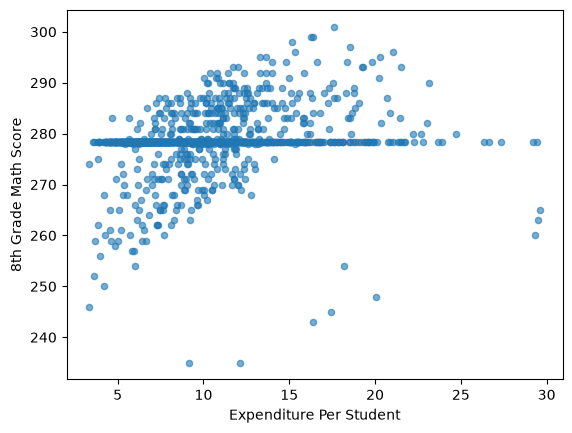

In [64]:
# @@@ 6
df.plot.scatter(x="EXPENDITURE_PER_STUDENT", y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('Expenditure Per Student')
plt.ylabel('8th Grade Math Score')

In the visualization for expenditure per student vs. 8th grade math score, there seems to be a moderately positive correlation because the higher expenditure per student data points somewhat predict whether the 8th grade math score will be lower (250) or higher (290). Additionally, there are many scores around 280, which are the nan scores that were replaced with the mean of the other scores, but these scores might make possible correlation weaker since they were assumed to be around the mean 8th grade math score but had various levels of instruction expenditure.

**Visualization 2**

Text(0, 0.5, '8th Grade Math Score')

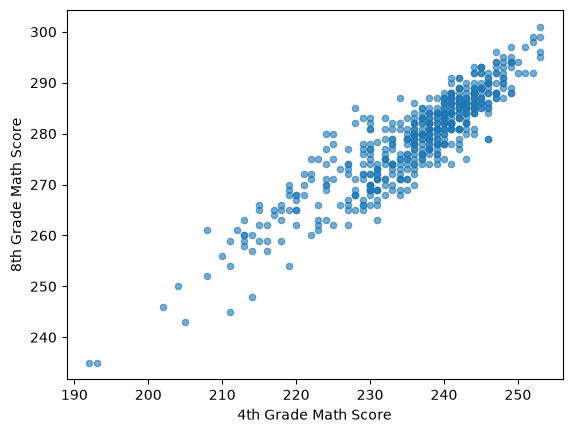

In [51]:
# @@@ 7
df.plot.scatter(x='AVG_MATH_4_SCORE', y='AVG_MATH_8_SCORE', alpha=0.6)
plt.xlabel('4th Grade Math Score')
plt.ylabel('8th Grade Math Score')

In the data visualization for 4th grade math score vs 8th grade math score, the correlation seems to be strong and positive because the data is clustered around a line with a positive slope. This indicates that 4th grade math score is a good predictor of how good the 8th grade math score will be. Higher 4th grade math scores correspond to higher 8th grade math scores.

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [91]:
from sklearn.model_selection import train_test_split

y.fillna(y.median(), inplace=True) #Median because math 8 scores are also left-skewed


561     262.0
562     279.0
563     271.0
564     266.0
565     267.0
        ...  
1219    288.0
1220    287.0
1221    271.0
1222    289.0
1223    287.0
Name: AVG_MATH_8_SCORE, Length: 357, dtype: float64

In [84]:
# @@@ 8

# X = 
# y = 
X = df[['ENROLL_8','AVG_READING_8_SCORE','AVG_MATH_4_SCORE', 'EXPENDITURE_PER_STUDENT', "FED_FUNDING_PERCENT"]].dropna()
y = df.loc[X.index]['AVG_MATH_8_SCORE']

In [85]:
# @@@ 9 

# X_train, X_test, y_train, y_test = train_test_split(
#      X, y, test_size=, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [86]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression


In [87]:
# @@@ 11
# create your model here
# model = 
model = LinearRegression()

In [88]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[0. ,0.54,0.75,0.04,0.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['ENROLL_8','AVG_READING_8_SCORE','AVG_MATH_4_SCORE', 'EXPENDITURE_PER_STUDENT','FED_FUNDING_PERCENT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-40.43
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [72]:
y_pred = model.predict(X_test)


## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [73]:
# @@@ 12
print(model.intercept_) 
print(model.coef_) 
model.score(X_test, y_test) #R2

18.747432500016203
[ 4.15559047e-06  1.01172591e+00 -2.97940886e-02  1.48851357e-01]


0.5632266663163822

We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

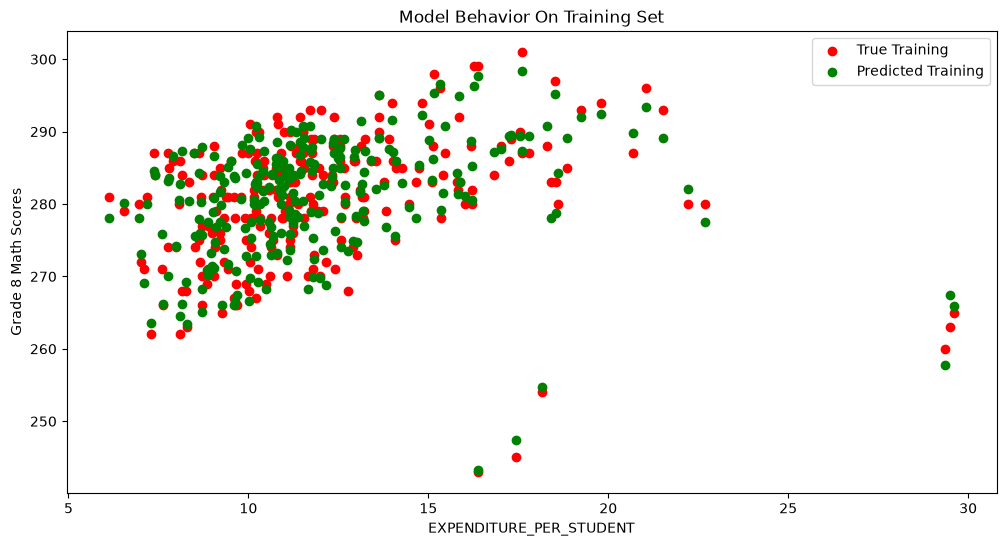

In [92]:
# @@@ 13

col_name = "EXPENDITURE_PER_STUDENT"


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('Grade 8 Math Scores')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

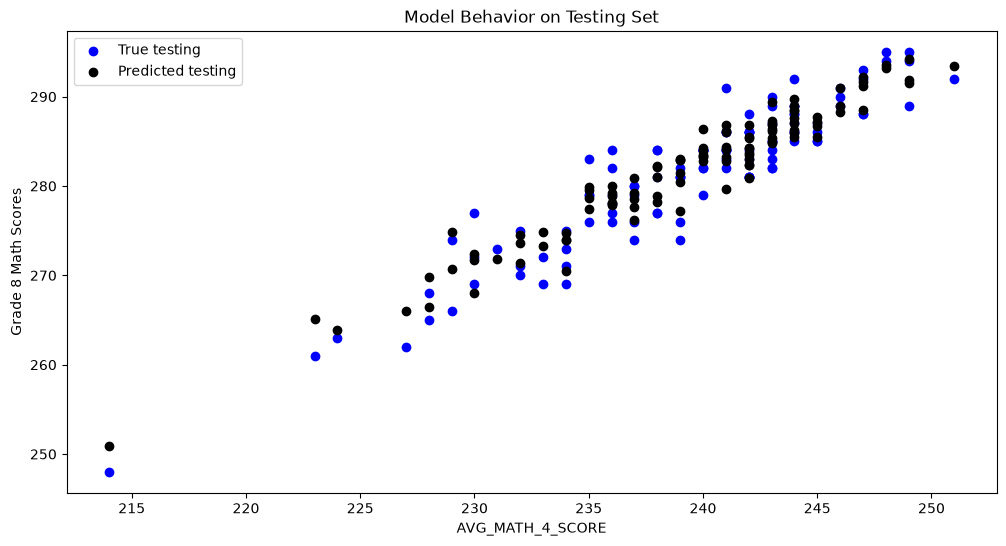

In [90]:
# @@@ 14


col_name = 'AVG_MATH_4_SCORE'


f = plt.figure(figsize=(12,6))
plt.scatter(X_test["AVG_MATH_4_SCORE"], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('Grade 8 Math Scores')
plt.title("Model Behavior on Testing Set")